# 8.1 How does a small artificial neural network learn?

**Question:** How can a network combine simple calculations to learn a curved classification boundary?

**Objectives:** follow a forward pass; explain weights, biases and activations; train a tiny ANN using gradient descent; interpret loss curves; evaluate on held-out geography.

**Prerequisites:** Python arrays, multiplication and basic plots. Matrix calculus is optional: read the gradient code as an implementation of “which direction reduces the error?” Lesson 7.1 is useful but not required. **Time:** 75-90 minutes.

**Data:** synthetic sites and an invented vegetation-response label. This is a conceptual exercise, not a model of actual vegetation. The ANN uses NumPy so its learning steps are visible; scikit-learn supplies scaling, metrics and baselines. No GPU, downloads or new dependencies.

Predict - run - explain - change one thing.

## The smallest useful mental picture

An **artificial neural network (ANN)** connects layers of numerical calculations. Here we use two inputs, one hidden layer of eight units, and one binary output: **2 -> 8 -> 1**, only 33 trainable numbers.

- A **weight** controls an input's contribution. A **bias** shifts the activation threshold.
- Each hidden unit computes a weighted sum, then applies **tanh**, a nonlinear function between -1 and 1. Without a nonlinear hidden activation, stacking these linear calculations collapses to a linear model.
- A **sigmoid** converts the output score into a value between 0 and 1. We interpret it as a model probability estimate.
- **Binary cross-entropy loss** penalizes incorrect probability estimates, especially confident mistakes.
- **Backpropagation** applies the chain rule to compute gradients. **Gradient descent** updates parameters: `new = old - learning_rate * gradient`.
- An **epoch** here is one pass over the full training set and one parameter update. Larger systems commonly use mini-batches instead.

This is a small fully connected network, not a convolutional network or language model. [Scikit-learn's neural-network guide](https://scikit-learn.org/stable/modules/neural_networks_supervised.html) provides a library-based next step.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, log_loss, ConfusionMatrixDisplay
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'course.py').exists())
OUT = ROOT/'data'/'generated'/'ann'
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)
n = 1000
sites = pd.DataFrame({'x_km': rng.uniform(0, 100, n), 'y_km': rng.uniform(0, 100, n)})
sites['moisture'] = rng.uniform(0, 1, n)
sites['elevation_m'] = rng.uniform(500, 2500, n)
# Toy positive class occupies an ellipse in FEATURE space, not a geographic boundary.
radius = ((sites.moisture - 0.5) / 0.32)**2 + ((sites.elevation_m - 1500) / 650)**2
sites['label'] = (radius < 1).astype(int)
flip = rng.random(n) < 0.04
sites.loc[flip, 'label'] = 1 - sites.loc[flip, 'label']
FEATURES = ['moisture', 'elevation_m']
X = sites[FEATURES].to_numpy()
y = sites.label.to_numpy().reshape(-1, 1)
train = (sites.x_km < 60).to_numpy()
validation = ((sites.x_km >= 60) & (sites.x_km < 80)).to_numpy()
test = (sites.x_km >= 80).to_numpy()
assert np.all(train.astype(int) + validation.astype(int) + test.astype(int) == 1)
for mask in [train, validation, test]:
    assert set(y[mask].ravel()) == {0, 1}
print({name: int(mask.sum()) for name, mask in [('train', train), ('validation', validation), ('test', test)]})
display(sites.head())

{'train': 603, 'validation': 200, 'test': 197}


,x_km,y_km,moisture,elevation_m,label
0,77.395605,6.206311,0.842732,2158.442282,0
1,43.887844,45.826204,0.446389,1688.191974,1
2,85.859792,12.903006,0.952975,989.709494,0
3,69.736803,15.232671,0.650795,1991.350001,1
4,9.417735,63.228281,0.115899,668.961791,0


## Scale using training data only

Moisture spans roughly 0-1 while elevation spans 500–2500. Their numerical units should not dictate optimization. Standardization subtracts the training mean and divides by the training standard deviation. Apply those same statistics to validation and test inputs; never fit a scaler on all rows before splitting.

The partitions use disjoint x-coordinate ranges, but this fixture has no realistic spatial dependence or regional distribution shift. It demonstrates a split protocol, not proof of real geographic transfer. Real projects may need buffers, grouped validation and independent labels.

,feature,training_mean,training_scale
0,moisture,0.491111,0.286097
1,elevation_m,1469.487599,563.996189


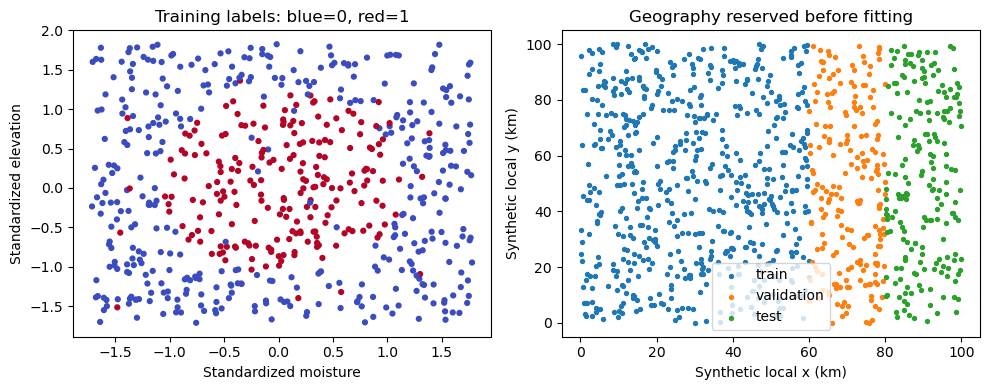

In [2]:
scaler = StandardScaler().fit(X[train])
X_train, X_val, X_test = [scaler.transform(X[mask]) for mask in [train, validation, test]]
y_train, y_val, y_test = [y[mask] for mask in [train, validation, test]]
assert np.allclose(X_train.mean(axis=0), 0, atol=1e-12)
display(pd.DataFrame({'feature': FEATURES, 'training_mean': scaler.mean_, 'training_scale': scaler.scale_}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap='coolwarm', vmin=0, vmax=1, s=12)
axes[0].set(xlabel='Standardized moisture', ylabel='Standardized elevation', title='Training labels: blue=0, red=1')
for name, mask in [('train', train), ('validation', validation), ('test', test)]:
    axes[1].scatter(sites.loc[mask, 'x_km'], sites.loc[mask, 'y_km'], s=8, label=name)
axes[1].set(xlabel='Synthetic local x (km)', ylabel='Synthetic local y (km)', title='Geography reserved before fitting')
axes[1].legend(); fig.tight_layout(); plt.show()

## Implement the forward pass

For a batch of rows: `H = tanh(X @ W1 + b1)` and `score = H @ W2 + b2`. The symbol `@` means matrix multiplication. Sigmoid maps each score to a probability estimate. Small random initial weights break symmetry so hidden units can learn different functions; biases start at zero.

For binary cross-entropy we calculate `log(1 + exp(score)) - y * score` using `logaddexp` for numerical stability. This is the same loss as the probability-based expression, without taking the log of zero.

In [3]:
def initialize(hidden=8, seed=7):
    random = np.random.default_rng(seed)
    return {'W1': random.normal(0, 0.5, (2, hidden)), 'b1': np.zeros((1, hidden)),
            'W2': random.normal(0, 0.5, (hidden, 1)), 'b2': np.zeros((1, 1))}

def forward(features, parameters):
    hidden = np.tanh(features @ parameters['W1'] + parameters['b1'])
    logits = hidden @ parameters['W2'] + parameters['b2']
    probability = np.exp(-np.logaddexp(0, -logits))  # Stable sigmoid.
    return hidden, logits, probability

def loss(features, labels, parameters):
    _, logits, _ = forward(features, parameters)
    return float(np.mean(np.logaddexp(0, logits) - labels * logits))

initial = initialize()
hidden, logits, probability = forward(X_train[:1], initial)
print('Input:', X_train[0])
print('Hidden activations:', hidden[0].round(3))
print('Output score:', float(logits[0, 0]), '| probability:', float(probability[0, 0]))
print('Trainable parameters:', sum(value.size for value in initial.values()))
assert sum(value.size for value in initial.values()) == 33
assert hidden.shape == (1, 8) and probability.shape == (1, 1)

Input: [-0.15631702  0.38777634]
Hidden activations: [-0.095 -0.143  0.116  0.138  0.056 -0.103 -0.01   0.03 ]
Output score: -0.1312145356592842 | probability: 0.46724335090099384
Trainable parameters: 33


## Backpropagation: how does the network know what to change?

For sigmoid plus cross-entropy, the output gradient is `(prediction - label) / number_of_rows`. Propagate it through the output weights and multiply by the tanh derivative, `1 - H²`, to reach the hidden layer. Matrix products then accumulate weight gradients across rows.

You do not need to memorize the equations to use the model. Identify the forward calculation, the loss, the gradient and the update as separate steps. The numerical check below perturbs one entry in each parameter array and verifies that backpropagation predicts its effect on loss.

In [4]:
def gradients(features, labels, parameters):
    hidden, _, probability = forward(features, parameters)
    output_error = (probability - labels) / len(features)
    hidden_error = (output_error @ parameters['W2'].T) * (1 - hidden**2)
    return {'W1': features.T @ hidden_error, 'b1': hidden_error.sum(axis=0, keepdims=True),
            'W2': hidden.T @ output_error, 'b2': output_error.sum(axis=0, keepdims=True)}

analytic = gradients(X_train[:20], y_train[:20], initial)
epsilon = 1e-5
for name in initial:
    plus = {key: value.copy() for key, value in initial.items()}
    minus = {key: value.copy() for key, value in initial.items()}
    plus[name].flat[0] += epsilon
    minus[name].flat[0] -= epsilon
    numerical = (loss(X_train[:20], y_train[:20], plus) - loss(X_train[:20], y_train[:20], minus)) / (2 * epsilon)
    assert np.isclose(numerical, analytic[name].flat[0], atol=1e-7, rtol=1e-4), name
print('Gradient checks passed for W1, b1, W2 and b2.')
one_step = {name: value - 0.1 * analytic[name] for name, value in initial.items()}
print('Loss before/after one update on the same 20 rows:',
      loss(X_train[:20], y_train[:20], initial), loss(X_train[:20], y_train[:20], one_step))

Gradient checks passed for W1, b1, W2 and b2.
Loss before/after one update on the same 20 rows: 0.6305948979344207 0.6277964911025726


## Train a small network and keep a validation checkpoint

Only training rows contribute gradients. Every 25 epochs we measure training and validation loss and save a copy of the parameters with the lowest validation loss. The epoch budget is fixed at 1500; this is checkpoint selection, not an early-stopping loop. Test labels are not used.

Training loss describes fit to the optimization data. Validation loss helps choose a checkpoint. Neither is the final estimate on unseen test geography. A decreasing loss does not guarantee improved accuracy, because loss also responds to changes in probability estimates.

Selected epoch: 1500


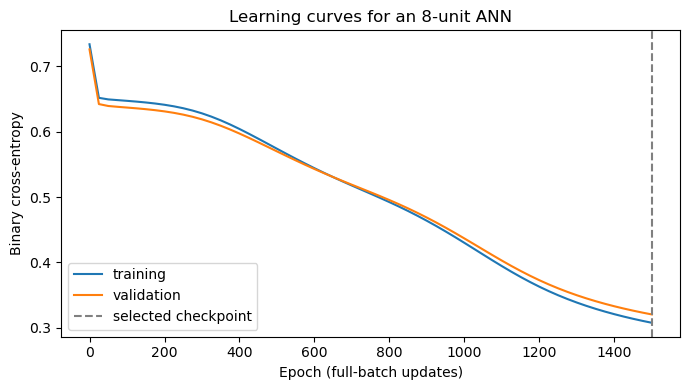

In [5]:
def train_network(features, labels, val_features, val_labels, hidden=8,
                  learning_rate=0.1, epochs=1500, seed=7):
    parameters = initialize(hidden, seed)
    history, best_loss, best_epoch, best_parameters = [], np.inf, None, None
    for epoch in range(epochs + 1):
        if epoch % 25 == 0 or epoch == epochs:
            train_loss = loss(features, labels, parameters)
            validation_loss = loss(val_features, val_labels, parameters)
            if not np.isfinite([train_loss, validation_loss]).all():
                raise ValueError('Nonfinite loss; inspect inputs and learning rate.')
            history.append({'epoch': epoch, 'train_loss': train_loss, 'validation_loss': validation_loss})
            if validation_loss < best_loss:
                best_loss, best_epoch = validation_loss, epoch
                best_parameters = {name: value.copy() for name, value in parameters.items()}
        if epoch < epochs:
            derivative = gradients(features, labels, parameters)
            for name in parameters:
                parameters[name] -= learning_rate * derivative[name]
    return best_parameters, pd.DataFrame(history), best_epoch

model, history, best_epoch = train_network(X_train, y_train, X_val, y_val)
print('Selected epoch:', best_epoch)
assert history.train_loss.iloc[-1] < history.train_loss.iloc[0]
assert all(np.isfinite(value).all() for value in model.values())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.epoch, history.train_loss, label='training')
ax.plot(history.epoch, history.validation_loss, label='validation')
ax.axvline(best_epoch, color='gray', linestyle='--', label='selected checkpoint')
ax.set(xlabel='Epoch (full-batch updates)', ylabel='Binary cross-entropy', title='Learning curves for an 8-unit ANN')
ax.legend(); fig.tight_layout(); fig.savefig(OUT/'learning_curves.png', dpi=140); plt.show()
history.to_csv(OUT/'loss_history.csv', index=False)

## Evaluate against simpler models

Freeze the architecture, learning settings, validation-selected checkpoint and the decision threshold of 0.5 before reading test results. Compare with a majority-class dummy and logistic regression, which produces a linear boundary in these two inputs. The ellipse was deliberately chosen to illustrate nonlinearity; this setup favors a nonlinear model and is not a general ANN benchmark.

Balanced accuracy averages the two class recalls; log loss evaluates probability estimates. Lower log loss is better, higher balanced accuracy is better. A probability close to one may still be wrong, especially under distribution shift.

,model,balanced_accuracy,log_loss
0,Majority baseline,0.500000,11.709613
1,Logistic regression,0.500000,0.636835
2,ANN: 2 → 8 → 1,0.887159,0.309143


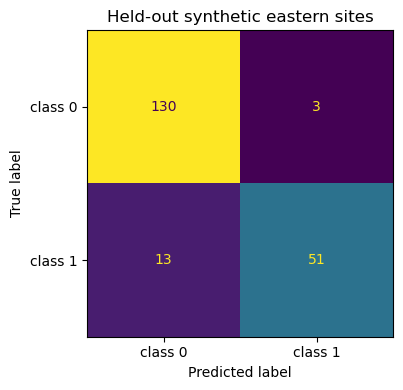

In [6]:
linear = LogisticRegression(random_state=42).fit(X_train, y_train.ravel())
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train.ravel())
test_probability = forward(X_test, model)[2].ravel()
rows = []
for name, probabilities in [('Majority baseline', dummy.predict_proba(X_test)[:, 1]),
                             ('Logistic regression', linear.predict_proba(X_test)[:, 1]),
                             ('ANN: 2 → 8 → 1', test_probability)]:
    predicted = (probabilities >= 0.5).astype(int)
    rows.append({'model': name, 'balanced_accuracy': balanced_accuracy_score(y_test.ravel(), predicted),
                 'log_loss': log_loss(y_test.ravel(), probabilities, labels=[0, 1])})
metrics = pd.DataFrame(rows)
display(metrics)
assert np.isfinite(test_probability).all() and ((test_probability >= 0) & (test_probability <= 1)).all()
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test.ravel(), (test_probability >= 0.5).astype(int),
                                       labels=[0, 1], display_labels=['class 0', 'class 1'], colorbar=False, ax=ax)
ax.set_title('Held-out synthetic eastern sites'); fig.tight_layout(); plt.show()
metrics.to_csv(OUT / 'test_metrics.csv', index=False)

## See the learned boundary

These plots show **feature space**, not a geographic map. Each point is a held-out site; its axes are moisture and elevation. The contour is the fixed 0.5 decision threshold. Compare a linear boundary with the curve assembled from eight nonlinear hidden units.

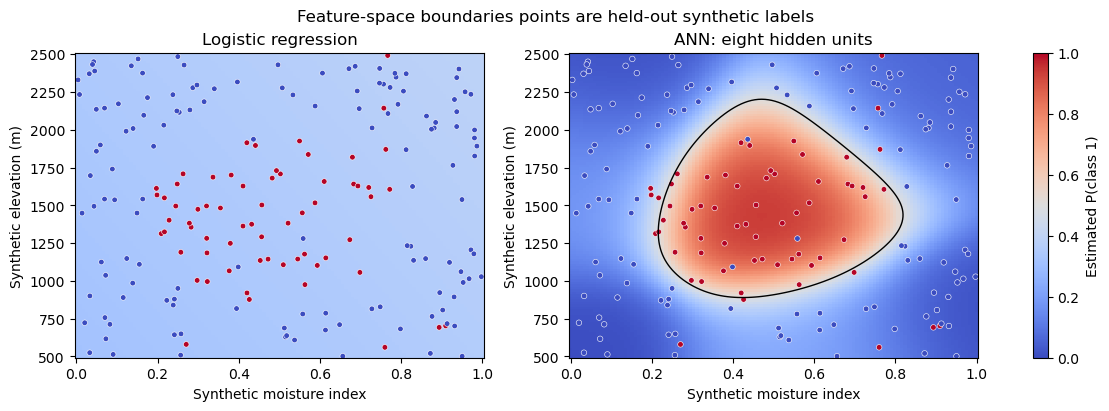

In [7]:
moisture, elevation = np.meshgrid(np.linspace(0, 1, 120), np.linspace(500, 2500, 120))
grid = scaler.transform(np.column_stack([moisture.ravel(), elevation.ravel()]))
linear_surface = linear.predict_proba(grid)[:, 1].reshape(moisture.shape)
ann_surface = forward(grid, model)[2].reshape(moisture.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, surface, title in zip(axes, [linear_surface, ann_surface], ['Logistic regression', 'ANN: eight hidden units']):
    im = ax.pcolormesh(moisture, elevation, surface, cmap='coolwarm', vmin=0, vmax=1, shading='auto')
    if surface.min() < 0.5 < surface.max():
        ax.contour(moisture, elevation, surface, levels=[0.5], colors='black', linewidths=1)
    ax.scatter(X[test, 0], X[test, 1], c=y_test.ravel(), cmap='coolwarm', vmin=0, vmax=1,
               edgecolors='white', linewidths=0.4, s=16)
    ax.set(title=title, xlabel='Synthetic moisture index', ylabel='Synthetic elevation (m)')
fig.colorbar(im, ax=axes, label='Estimated P(class 1)')
fig.suptitle('Feature-space boundaries points are held-out synthetic labels')
fig.savefig(OUT/'decision_boundaries.png', dpi=140); plt.show()

## Your independent challenge

1. Predict the effect of changing hidden units from 8 to 2, or learning rate from 0.1 to 0.01. Change **one** factor, holding the split, seed and epoch budget constant. Use training and validation only.
2. Compare the loss curves and validation loss at the selected checkpoint. Explain capacity versus optimization speed; more units do not guarantee better generalization.
3. Inspect one validation row's hidden activations and output using `forward`. Explain why a hidden activation is not itself a cover-class label.
4. Explain why fitting the scaler on all rows leaks information and why repeatedly comparing variants on the existing test set invalidates it as a held-out test.

**Submit:** a prediction, one experiment table, overlaid learning curves and a 100-word explanation. The existing test is now observed; reserve new data before making further final-performance claims.

In [8]:
# Your experiment: train_network(..., hidden=2) or learning_rate=0.01. Do not tune using X_test/y_test.

<details><summary>Solution guidance - open after trying</summary>

Call `train_network` with the original training/validation arrays and just one changed argument. Compare the minimum recorded validation loss, selected epoch and training curve. A smaller learning rate may need more epochs; poor performance at a fixed budget is not proof that the architecture cannot learn. Two hidden units have less capacity to approximate an enclosed curved region. Random initialization also matters, so a later robustness study should repeat fixed settings across seeds without selecting the luckiest test outcome. A hidden unit can respond to a combination of features; it does not necessarily have a unique physical interpretation.

</details>

## Check yourself and assessment

What changes during learning? What stays fixed? What would happen if we removed tanh? Why can validation loss rise while training loss falls?

| Criterion | Points | Evidence |
|---|---:|---|
| Forward-pass understanding | 3 | Explains inputs, weights, bias, hidden activation and output |
| Learning mechanics | 2 | Distinguishes loss, gradient and update; interprets curves |
| Independent experiment | 3 | One controlled change, validation-only comparison and explanation |
| Evaluation and communication | 2 | Training-only scaler; baseline; synthetic disclosure and limitations |

**Mastery target:** 8/10, with no test-driven model selection. Reward reasoning, not the highest score.

## Transfer to real geospatial data

Obtain independent labels and predictors with matched spatial/temporal support, documented units, CRS and nodata handling. Fit imputation and scaling only on training data. Reserve meaningful geographic groups and consider spatial buffers. Compare a simple baseline, a decision tree and an ANN on the same evaluation cohort. Report class-specific errors, calibration and regional failures before making environmental claims. The toy label rule here cannot serve as independent validation of a real process.

## Educator note

Suggested 90 minutes: 10 for the network concepts, 15 for data/scaling, 20 for a forward pass and gradient update, 15 for training/validation, and 30 for the independent experiment and discussion. Beginners can focus on inputs and outputs of `gradients`; learners with calculus can derive and extend the numerical gradient checks.

For a short demonstration, show the first row's hidden activations, the loss curve and the curved feature-space boundary. This lesson adds the question “how does learning change the weights?” to the decision-tree lesson's “how does a model reach a decision?”